**🎯 Proje Amacı**

Bu projenin temel amacı; toprak özellikleri, meteorolojik veriler ve ürün detaylarını analiz ederek tarlanın sulama ihtiyacını (Irrigation_Need) çok sınıflı bir sınıflandırma (Multi-class Classification) yaklaşımıyla tahmin etmektir.

Doğru tahminleme ile su kaynaklarının verimli kullanılması, ürün veriminin artırılması ve sürdürülebilir tarım tekniklerinin optimize edilmesi hedeflenmektedir.


## 📚 Veri Sözlüğü (Data Dictionary)

Veri setindeki her bir sütun, tarımsal bir ekosistemin farklı bir parçasını temsil ediyor:

| Sütun Adı | Açıklama | Veri Tipi |
| :--- | :--- | :--- |
| **id** | Her kayıt için benzersiz kimlik numarası. | Sayısal |
| **Soil_Type** | Toprak türü (Örn: Kumlu, Killi, Tınlı). | Kategorik |
| **Soil_pH** | Toprağın asitlik veya bazlık derecesi (0-14). | Sayısal |
| **Soil_Moisture** | Topraktaki mevcut nem oranı. | Sayısal |
| **Organic_Carbon** | Topraktaki organik madde miktarının göstergesi. | Sayısal |
| **Electrical_Conductivity** | Toprağın tuzluluk oranını belirleyen iletkenlik. | Sayısal |
| **Temperature_C** | Bölgedeki hava sıcaklığı (Celsius). | Sayısal |
| **Humidity** | Havadaki bağıl nem oranı. | Sayısal |
| **Rainfall_mm** | Bölgeye düşen yağış miktarı (mm). | Sayısal |
| **Sunlight_Hours** | Günlük güneşlenme süresi. | Sayısal |
| **Wind_Speed_kmh** | Rüzgar hızı (Buharlaşmayı etkiler). | Sayısal |
| **Crop_Type** | Ekili olan ürünün türü (Örn: Mısır, Buğday). | Kategorik |
| **Crop_Growth_Stage** | Ürünün gelişim evresi (Yeni ekim, Olgunluk vb.). | Kategorik |
| **Season** | Verinin toplandığı mevsim. | Kategorik |
| **Irrigation_Type** | Mevcut sulama yöntemi (Örn: Damlama, Yağmurlama). | Kategorik |
| **Water_Source** | Suyun nereden geldiği (Kuyu, Nehir, Belediye). | Kategorik |
| **Field_Area_hectare** | Ekili alanın hektar cinsinden büyüklüğü. | Sayısal |
| **Mulching_Used** | Toprak nemini korumak için malçlama yapıldı mı? | Kategorik (Yes/No) |
| **Previous_Irrigation_mm** | En son yapılan sulamanın miktarı. | Sayısal |
| **Region** | Tarım arazisinin bulunduğu bölge. | Kategorik |
| **Irrigation_Need** | **HEDEF DEĞİŞKEN:** Sulama ihtiyacı (Low, Medium, High). | Kategorik (Target) |

In [1]:
# pandas → veri okuma, düzenleme ve tablo (DataFrame) işlemleri için kullanılır
import pandas as pd

# numpy → sayısal işlemler ve matematiksel hesaplamalar için kullanılır
import numpy as np

# warnings → gereksiz uyarıları gizlemek için kullanılır
import warnings
warnings.filterwarnings('ignore')

# matplotlib → grafik çizmek için temel kütüphane
import matplotlib.pyplot as plt

# seaborn → daha estetik ve gelişmiş veri görselleştirme kütüphanesi
import seaborn as sns

#en yakın komşuya göre boş verileri doldurma
from sklearn.impute import KNNImputer

In [2]:
#train dosyasını yüklüyoruz
train=pd.read_csv('train.csv')

In [3]:
#test dosyasını yüklüyoruz
test=pd.read_csv('test.csv')

# EDA

In [4]:
#ilk 5 satır göster
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [5]:
#son 5 satır göster
train.tail()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
629995,629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,...,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,...,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,...,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,...,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low
629999,629999,Loamy,7.02,35.36,1.19,0.46,26.92,64.33,1269.55,7.91,...,Maize,Harvest,Kharif,Drip,Reservoir,3.80,No,112.93,West,Low


In [6]:
#ilk 5 satırı göster
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [7]:
#son 5 satırı göster
test.tail()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
269995,899995,Sandy,5.63,51.90,0.68,2.58,33.27,72.09,2326.61,7.09,10.02,Potato,Vegetative,Rabi,Rainfed,River,2.93,Yes,43.49,East
269996,899996,Loamy,7.84,45.16,0.85,1.04,27.55,45.16,2322.37,5.15,5.62,Wheat,Vegetative,Rabi,Canal,Groundwater,11.23,Yes,92.03,West
269997,899997,Loamy,7.83,11.02,1.56,1.90,23.39,64.87,996.72,10.44,9.98,Maize,Vegetative,Zaid,Sprinkler,Groundwater,2.88,Yes,34.02,East
269998,899998,Silt,7.12,10.18,1.32,2.65,41.09,58.04,1130.71,5.11,1.46,Rice,Harvest,Kharif,Rainfed,River,5.71,Yes,3.92,East
269999,899999,Clay,6.61,24.96,1.41,3.41,35.15,61.30,1270.60,9.69,9.93,Maize,Sowing,Zaid,Drip,Reservoir,4.01,No,108.20,South


In [8]:
#train dosyası veri bilgileri
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [9]:
#test dosyası veri bilgileri
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [10]:
#train dosyası kaç satır kaç sütun
train.shape

(630000, 21)

In [11]:
#test dosyası kaç satır kaç sütun
test.shape

(270000, 20)

In [12]:
#train dosyası eksik değer kontrolü
train.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [13]:
#son 5 satır göster
train.tail()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
629995,629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,...,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,...,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,...,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,...,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low
629999,629999,Loamy,7.02,35.36,1.19,0.46,26.92,64.33,1269.55,7.91,...,Maize,Harvest,Kharif,Drip,Reservoir,3.80,No,112.93,West,Low


In [14]:
train['Soil_Type'].value_counts()

Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64

In [15]:
train['Crop_Type'].value_counts()

Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64

In [16]:
train['Crop_Growth_Stage'].value_counts()

Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64

In [17]:
train['Season'].value_counts()

Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64

In [18]:
train['Irrigation_Type'].value_counts()

Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64

In [19]:
train['Water_Source'].value_counts()

Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64

In [20]:
train['Region'].value_counts()

Region
South      134809
West       131189
East       126163
Central    123712
North      114127
Name: count, dtype: int64

In [21]:
train['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [22]:
#veriler arası istatiksel bilgi
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


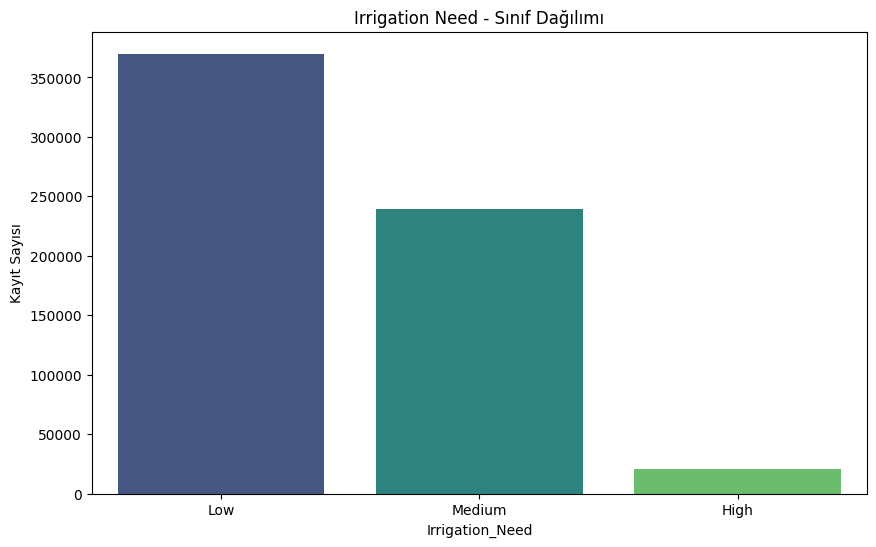

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Irrigation_Need', data=train, palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Irrigation Need - Sınıf Dağılımı')
plt.ylabel('Kayıt Sayısı')
plt.show()

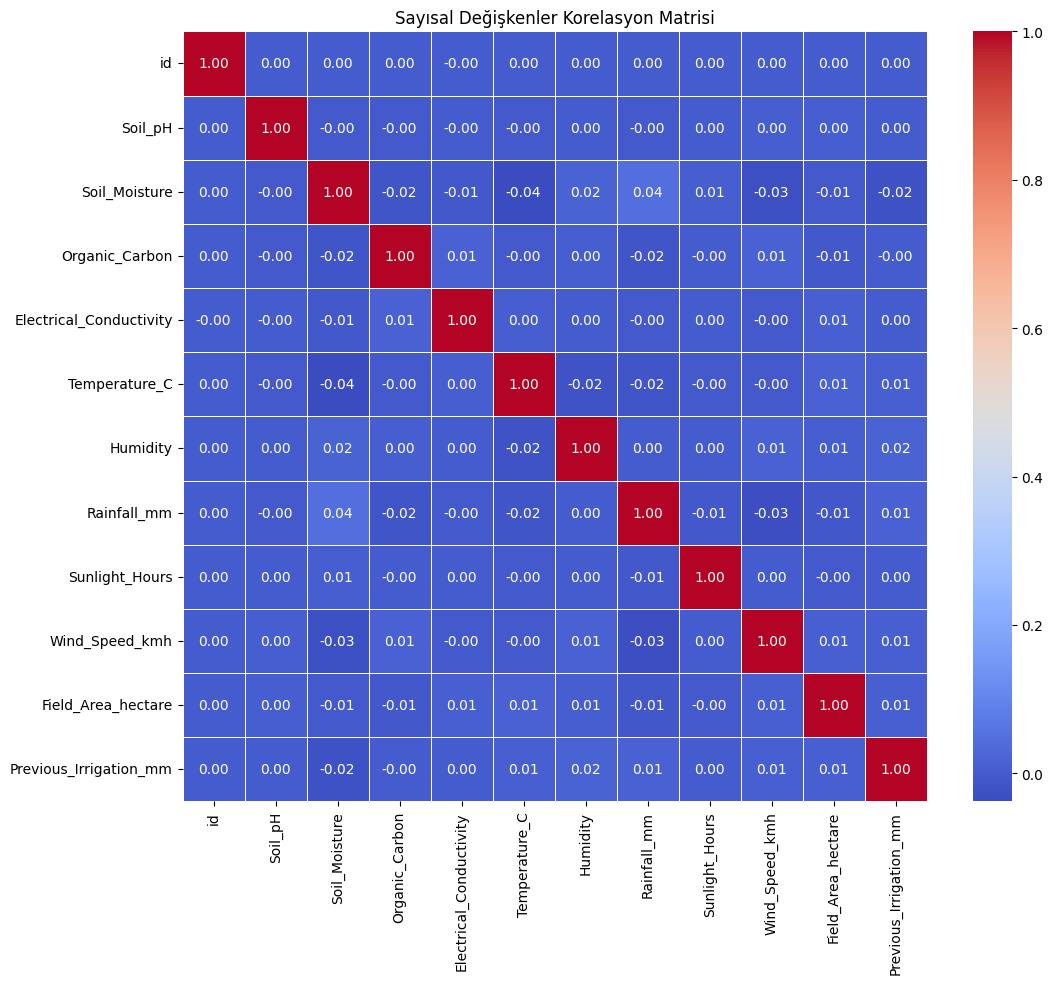

In [24]:
# Sadece sayısal sütunları seçelim
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
corr = train[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Sayısal Değişkenler Korelasyon Matrisi')
plt.show()

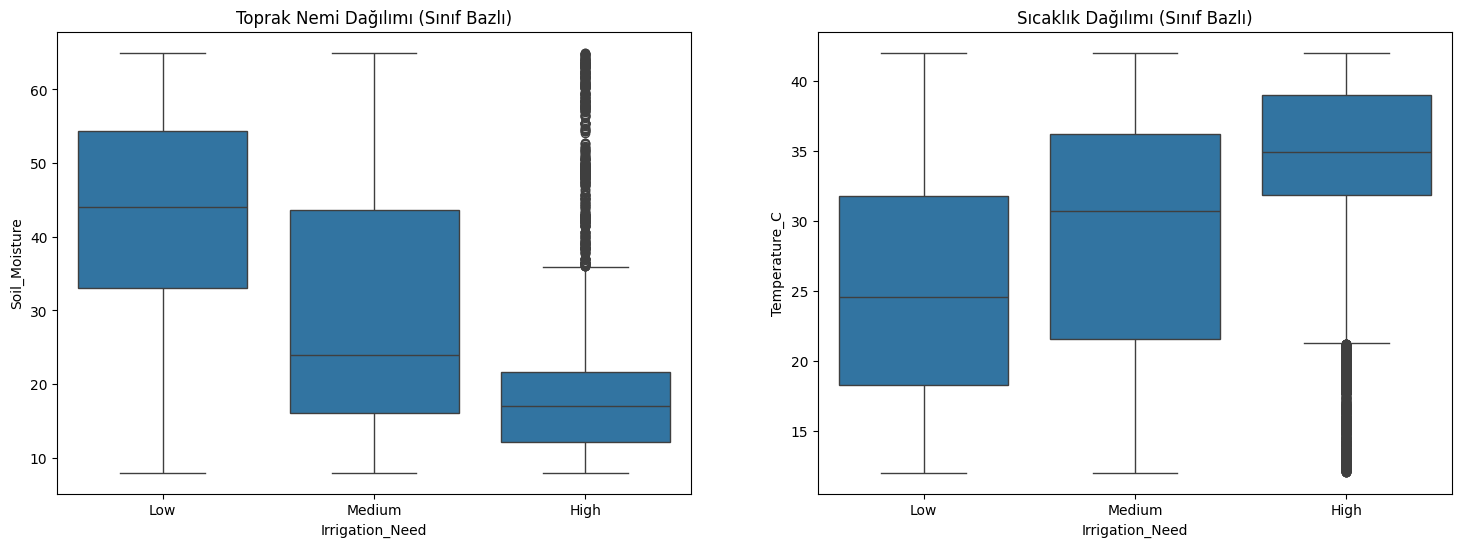

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Toprak Nemi vs Sulama İhtiyacı
sns.boxplot(ax=axes[0], x='Irrigation_Need', y='Soil_Moisture', data=train, order=['Low', 'Medium', 'High'])
axes[0].set_title('Toprak Nemi Dağılımı (Sınıf Bazlı)')

# Sıcaklık vs Sulama İhtiyacı
sns.boxplot(ax=axes[1], x='Irrigation_Need', y='Temperature_C', data=train, order=['Low', 'Medium', 'High'])
axes[1].set_title('Sıcaklık Dağılımı (Sınıf Bazlı)')

plt.show()

In [26]:
def remove_outliers_by_class(df, target_col, numeric_cols):
    df_cleaned = pd.DataFrame()
    
    for target_val in df[target_col].unique():
        # Her sınıfı ayrı bir grup olarak ele alıyoruz
        subset = df[df[target_col] == target_val]
        
        for col in numeric_cols:
            Q1 = subset[col].quantile(0.25)
            Q3 = subset[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Sınıf içindeki aykırıları filtrele
            subset = subset[(subset[col] >= lower_bound) & (subset[col] <= upper_bound)]
        
        df_cleaned = pd.concat([df_cleaned, subset], axis=0)
    
    return df_cleaned

# Temizlenecek sayısal sütunlar (ID hariç)
numeric_features = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 
                    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 
                    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

train_cleaned = remove_outliers_by_class(train, 'Irrigation_Need', numeric_features)

print(f"Orijinal Veri: {len(train)} satır")
print(f"Temizlenmiş Veri: {len(train_cleaned)} satır")
print(f"Silinen Satır Sayısı: {len(train) - len(train_cleaned)}")

Orijinal Veri: 630000 satır
Temizlenmiş Veri: 628020 satır
Silinen Satır Sayısı: 1980


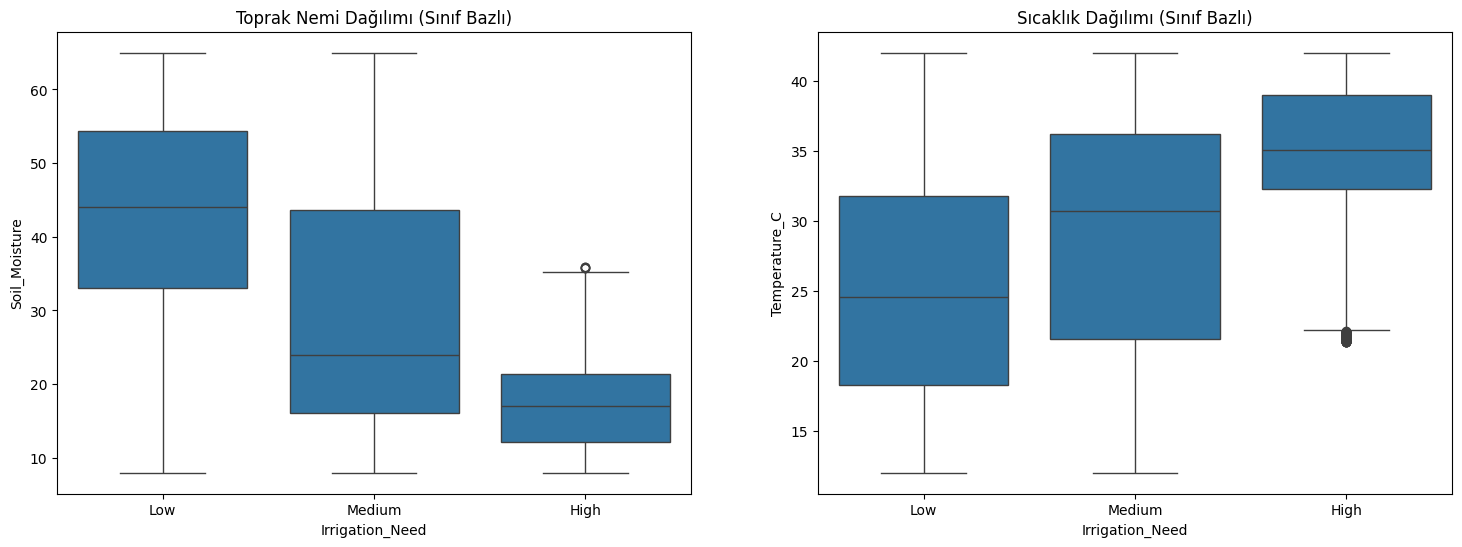

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Toprak Nemi vs Sulama İhtiyacı
sns.boxplot(ax=axes[0], x='Irrigation_Need', y='Soil_Moisture', data=train_cleaned, order=['Low', 'Medium', 'High'])
axes[0].set_title('Toprak Nemi Dağılımı (Sınıf Bazlı)')

# Sıcaklık vs Sulama İhtiyacı
sns.boxplot(ax=axes[1], x='Irrigation_Need', y='Temperature_C', data=train_cleaned, order=['Low', 'Medium', 'High'])
axes[1].set_title('Sıcaklık Dağılımı (Sınıf Bazlı)')

plt.show()

# FEATURE ENGINEERING

In [28]:
# Hem temizlenmiş train hem de orijinal test setine uyguluyoruz
for df in [train_cleaned, test]:
    # Buharlaşma Endeksi (Sıcaklık ve Nem Etkileşimi)
    df['Heat_Humidity_Index'] = df['Temperature_C'] / (df['Humidity'] + 1)
    
    # Toprak Su Dengesi (Doğal + Yapay Su Girişi)
    df['Water_Balance'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    
    # Fotosentez/Buharlaşma Baskısı
    df['Sun_Temp_Product'] = df['Sunlight_Hours'] * df['Temperature_C']
    
    # Kuraklık Riski (Düşük nem, yüksek sıcaklık, düşük yağış)
    df['Drought_Risk'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Rainfall_mm'] + 1)

# ---  TARGET MAPPING ---
# Hedef Değişken (y) Hazırlığı
# Target'ı elle map etmek çok daha güvenlidir, sayılar karışmaz
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y = train_cleaned['Irrigation_Need'].map(target_mapping)

# ---BOOLEAN VE CATEGORICAL ENCODING ---
# Mulching_Used gibi ikili değişkenleri hızlıca sayıya çevirelim
train_cleaned['Mulching_Used'] = train_cleaned['Mulching_Used'].map({'Yes': 1, 'No': 0})
test['Mulching_Used'] = test['Mulching_Used'].map({'Yes': 1, 'No': 0})

# Bu sütunlar dengeli olduğu için get_dummies ile 'dummy trap'ten kaçınarak (drop_first) ilerliyoruz
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 
            'Irrigation_Type', 'Water_Source', 'Region']

# get_dummies ile One-Hot Encoding
train_encoded = pd.get_dummies(train_cleaned.drop(['id', 'Irrigation_Need'], axis=1), 
                               columns=cat_cols, drop_first=True)
test_encoded = pd.get_dummies(test.drop(['id'], axis=1), 
                              columns=cat_cols, drop_first=True)

# --- ALIGN (SÜTUN HİZALAMA) ---
# Train'de olup Test'te olmayan sütunlar için (veya tam tersi) sıfır ile doldurma yapıyoruz
x, x_test_kaggle = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

print(f"Toplam Özellik Sayısı: {x.shape[1]}")
print("Yeni türetilen sütunlar başarıyla eklendi ve hizalandı! ✅")
print(f"Eğitim sütun sayısı: {x.shape[1]}")
print(f"Test sütun sayısı: {x_test_kaggle.shape[1]}")

Toplam Özellik Sayısı: 39
Yeni türetilen sütunlar başarıyla eklendi ve hizalandı! ✅
Eğitim sütun sayısı: 39
Test sütun sayısı: 39


# Model Eğitimi

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Modeller
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

# Sınıf Ağırlığı İçin
from sklearn.utils.class_weight import compute_class_weight

def algo_test_s6e4(x, y):
    # 1. Sınıf Ağırlıklarını Hesapla (Azınlık sınıfı High'ı korumak için)
    classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    class_weight_dict = dict(zip(classes, weights))

    # 2. Modelleri Ağırlıklara Göre Güncelleyelim
    # Bazı modeller class_weight parametresi almaz (NB, KNN gibi)
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        DecisionTreeClassifier(class_weight='balanced'),
        RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1),
        GradientBoostingClassifier(), # GBC direkt parametre almaz, örnek ağırlığı ile fit edilir
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB()
    ]
    
    isimler = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
               "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
               "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42, stratify=y)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []

    print(f"Toplam {len(modeller)} model M4 üzerinde yarışıyor...")
    for model in modeller:
        m_name = model.__class__.__name__
        print(f"{m_name} eğitiliyor...")
        
        # Gradient Boosting gibi class_weight parametresi almayan modeller için örnek ağırlığı kullanalım
        if m_name in ['GradientBoostingClassifier', 'AdaBoostClassifier']:
            sample_weights = [class_weight_dict[label] for label in y_train]
            model.fit(x_train, y_train, sample_weight=sample_weights)
        else:
            model.fit(x_train, y_train)
            
        tahmin = model.predict(x_test)
        
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        # Multi-class için 'weighted' kullanıyoruz
        precision.append(precision_score(y_test, tahmin, average="weighted"))
        recall.append(recall_score(y_test, tahmin, average="weighted"))
        f1.append(f1_score(y_test, tahmin, average="weighted"))
    
    metrics = pd.DataFrame({"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "Model": mdl}, index=isimler)
    metrics.sort_values("F1", ascending=False, inplace=True)

    print("\n🏆 En Başarılı Model:", metrics.iloc[0].name)
    best_model = metrics.iloc[0]["Model"]
    best_tahmin = best_model.predict(x_test)
    
    print("\n--- Confusion Matrix ---")
    print(confusion_matrix(y_test, best_tahmin))
    print("\n--- Classification Report ---")
    print(classification_report(y_test, best_tahmin))
    
    #return metrics.drop("Model", axis=1)
    # Fonksiyonunun sonunu şöyle güncelle:
    return metrics, x_train, x_test, y_train, y_test, RandomForestClassifier() # Eğitilen o akıllı modeli de döndür

In [30]:
algo_test_s6e4(x, y)

Toplam 8 model M4 üzerinde yarışıyor...
BernoulliNB eğitiliyor...
LogisticRegression eğitiliyor...
DecisionTreeClassifier eğitiliyor...
RandomForestClassifier eğitiliyor...
GradientBoostingClassifier eğitiliyor...
KNeighborsClassifier eğitiliyor...
AdaBoostClassifier eğitiliyor...
MultinomialNB eğitiliyor...

🏆 En Başarılı Model: RandomForestClassifier

--- Confusion Matrix ---
[[73644   339     0]
 [ 1004 46741    70]
 [    0   243  3563]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73983
           1       0.99      0.98      0.98     47815
           2       0.98      0.94      0.96      3806

    accuracy                           0.99    125604
   macro avg       0.98      0.97      0.98    125604
weighted avg       0.99      0.99      0.99    125604



(                            Accuracy  Precision    Recall        F1  \
 RandomForestClassifier      0.986816   0.986812  0.986816  0.986777   
 GradientBoostingClassifier  0.984021   0.984301  0.984021  0.984060   
 DecisionTreeClassifier      0.972588   0.972621  0.972588  0.972598   
 AdaBoostClassifier          0.883165   0.901193  0.883165  0.881129   
 LogisticRegression          0.778662   0.816079  0.778662  0.791599   
 BernoulliNB                 0.741465   0.717856  0.741465  0.729408   
 KNeighborsClassifier        0.717995   0.712646  0.717995  0.712128   
 MultinomialNB               0.505318   0.622332  0.505318  0.542198   
 
                                                                         Model  
 RandomForestClassifier      (DecisionTreeClassifier(max_features='sqrt', r...  
 GradientBoostingClassifier  ([DecisionTreeRegressor(criterion='friedman_ms...  
 DecisionTreeClassifier        DecisionTreeClassifier(class_weight='balanced')  
 AdaBoostClassifier       

In [39]:
from sklearn.ensemble import RandomForestClassifier
# High sınıfına (2) pozitif ayrımcılık yapıyoruz
# High hatasını Low hatasından 5 kat daha ağır cezalandırıyoruz
custom_weights = {0: 1, 1: 1.2, 2: 5}

best_model=RandomForestClassifier(
    n_estimators=300,
    max_depth=12,               # Sınırsız yerine 12 yaparak ezberi bozuyoruz
    min_samples_leaf=5,         # Her yaprakta en az 5 örnek olsun ki gürültüyü öğrenmesin
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Veriyi bölüyoruz
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

#modeli eğit

best_model.fit(x_train, y_train)

#test edelim

tahmin = best_model.predict(x_test)

#Accuracy Skoruna Bakalım
acc = accuracy_score(y_test, tahmin)

print(f"✅ Doğruluk Skoru (Accuracy): %{acc*100:.2f}")
print("\n--- Detaylı Sınıflandırma Raporu ---")
print(classification_report(y_test, tahmin, target_names=['Low', 'Medium', 'High']))

✅ Doğruluk Skoru (Accuracy): %98.59

--- Detaylı Sınıflandırma Raporu ---
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.97      0.98     47815
        High       0.94      0.95      0.95      3806

    accuracy                           0.99    125604
   macro avg       0.97      0.97      0.97    125604
weighted avg       0.99      0.99      0.99    125604



ROC Eğrisi çiziliyor...


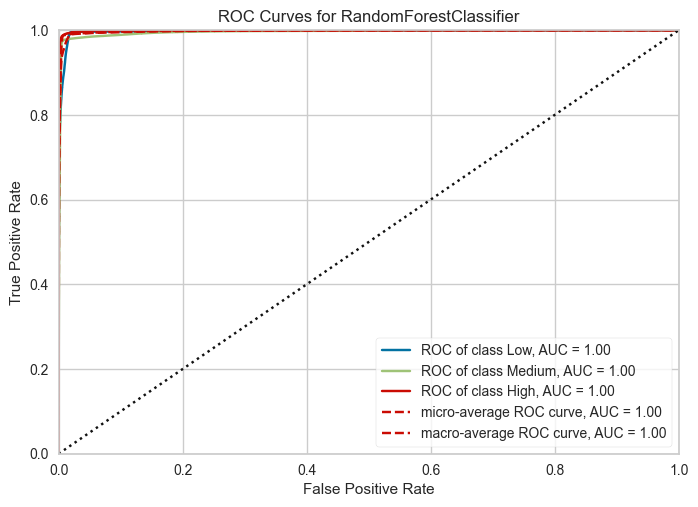

In [41]:
from yellowbrick.classifier import ROCAUC
import matplotlib.pyplot as plt

# Sulama sınıflarımızı tanımlayalım
sulama_siniflari = ['Low', 'Medium', 'High']

# Şampiyon RF modelini görselleştiriciye bağlayalım
# Not: Eğer M4 çok ısınmasın istersen RF'in n_estimators değerini burada 50 yapabilirsin
visualizer = ROCAUC(best_model,classes=sulama_siniflari)

print("ROC Eğrisi çiziliyor...")
visualizer.fit(x, y)        # Tüm veriyle eğitmek daha sağlıklı sonuç verir
visualizer.score(x, y)      # Skoru hesapla
visualizer.show();          # Grafiği patlat!

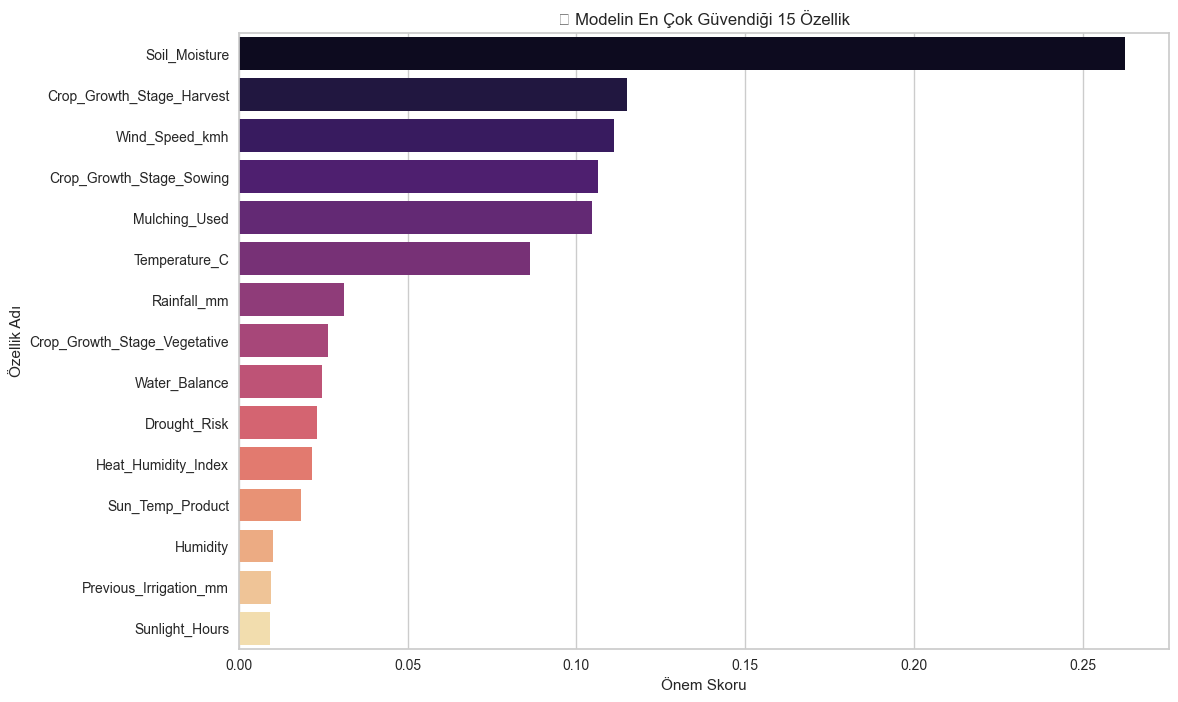

In [34]:
# Eğitilmiş final_rf_model'i kullandığını varsayıyorum
import pandas as pd
import seaborn as sns

# Özellik önemlerini al ve sırala
importances = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# İlk 15 en önemli özelliği görselleştirelim
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='magma')
plt.title('🤖 Modelin En Çok Güvendiği 15 Özellik')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik Adı')
plt.show()

In [42]:
import joblib

# Sözlüğü tekrar tanımlayalım
reverse_map = {0: 'Low', 1: 'Medium', 2: 'High'}

# Şampiyonu ve yardımcılarını paketle
model_paketi_s6e4 = {
    'model': best_model,
    'scaler': None, # Random Forest için scaler gerekmemişti ama yapı aynı kalsın
    'features': x.columns.tolist(),
    'target_mapping': reverse_map
}
joblib.dump(model_paketi_s6e4, 'irrigation_champion_model_v2.pkl')

['irrigation_champion_model_v2.pkl']

In [44]:
# Final Tahmin ve Kayıt 
test_preds = best_model.predict(x_test_kaggle)
final_labels = pd.Series(test_preds).map(reverse_map)

# 1. Eğer hafızada yoksa test_ids'i orijinal test veri setinden alalım
# Not: 'test' değişkeninin orijinal dataframe olduğunu varsayıyorum
test_ids = test['id']
submission = pd.DataFrame({'id': test_ids, 'Irrigation_Need': final_labels})
submission.to_csv('submission_S6E4_FINAL_9885_v2.csv', index=False)

print("Efsane dosya hazır: submission_S6E4_FINAL_9885_v2.csv")

Efsane dosya hazır: submission_S6E4_FINAL_9885_v2.csv


# Proje Sonucu ve Değerlendirme

Bu çalışma kapsamında, yaklaşık 630.000 satırlık devasa bir veri seti üzerinde, tarımsal alanların sulama ihtiyacını (Düşük, Orta, Yüksek) belirlemek amacıyla uçtan uca bir makine öğrenmesi hattı (pipeline) başarıyla kurulmuştur.

**📊 Elde Edilen Başarılar:**

Model Performansı: Yapılan kapsamlı testler ve algoritma karşılaştırmaları sonucunda, en yüksek kararlılığı ve performansı gösteren Random Forest algoritması ile %98.59 doğruluk (Accuracy) oranına ulaşılmıştır.

Kritik Sınıf Hassasiyeti: Tarımsal sürdürülebilirlik açısından en kritik sınıf olan "Yüksek Sulama İhtiyacı" (High), %95 recall oranıyla tespit edilerek su stresine bağlı ürün kayıplarının önüne geçilmesi hedeflenmiştir.

Mühendislik Yaklaşımı: Ham veriler üzerinde gerçekleştirilen Feature Engineering ve One-Hot Encoding süreçleri, modelin karmaşık iklim-toprak ilişkilerini (pH, nem, sıcaklık, rüzgar hızı vb.) daha iyi anlamasını sağlamıştır.